# Phase 2b — Évaluation Multi-LLMs sur GKMC
**GeoR2LLMs — M2 IA, Université Toulouse III Paul Sabatier**

## Objectif
Comparer les performances de 5 LLMs différents dans une configuration RAG
pour la question-réponse géographique sur le dataset **GKMC** (Geographic Knowledge Multiple Choice).

| LLM | Famille | Taille | HuggingFace ID |
|-----|---------|--------|----------------|
| Qwen3-0.6B | Qwen | 0.6B | Qwen/Qwen3-0.6B |
| Qwen3-1.7B | Qwen | 1.7B | Qwen/Qwen3-1.7B |
| Llama-3.2-1B | Meta | 1.0B | meta-llama/Llama-3.2-1B-Instruct |
| Llama-3.2-3B | Meta | 3.0B | meta-llama/Llama-3.2-3B-Instruct |
| Ministral-3B | Mistral | 3.0B | mistralai/Ministral-3-3B-Instruct-2512 |

Retriever commun : BAAI/bge-m3 + FAISS | Corpus : Wikipedia FR | Dataset : **GKMC**

> **Note** : Ce notebook reprend la même architecture que la Phase 2a (GeoSQA)
> afin de permettre une comparaison directe entre les deux benchmarks.

## Étape 1 — Installation et Configuration

In [1]:
# Installation de toutes les dépendances nécessaires
!pip install -q faiss-cpu sentence-transformers "transformers>=4.51.0" \
    accelerate datasets langchain-text-splitters \
    tqdm numpy pandas scikit-learn matplotlib seaborn \
    sentencepiece protobuf scipy
!pip install -q huggingface_hub

import torch
import random
import numpy as np
import os
import gc

# — Vérification GPU -----------------------------------------------------------
print("=" * 60)
print("CONFIGURATION MATÉRIELLE")
print("=" * 60)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU détecté : {gpu_name}")
    print(f"Mémoire GPU : {gpu_mem:.1f} Go")
    DEVICE = 'cuda'
else:
    print("Aucun GPU détecté — exécution sur CPU (sera lent)")
    DEVICE = 'cpu'

# — Configuration globale -------------------------------------------------------
CONFIG = {
    'embedding_model': 'BAAI/bge-m3',
    'chunk_size': 512,
    'chunk_overlap': 50,
    'top_k': 5,
    'max_new_tokens': 100,
    'n_wiki_articles': 300,
    'dataset_name': 'rfr2003/Geo_Benchmark',
    'dataset_config': 'GKMC',
}

# — Modèles à comparer -----------------------------------------------------------
MODELS = {
    'Qwen3-0.6B':  {'id': 'Qwen/Qwen3-0.6B',                        'family': 'Qwen',   'size_B': 0.6, 'type': 'qwen3'},
    'Qwen3-1.7B':  {'id': 'Qwen/Qwen3-1.7B',                        'family': 'Qwen',   'size_B': 1.7, 'type': 'qwen3'},
    'Llama-3.2-1B':{'id': 'meta-llama/Llama-3.2-1B-Instruct',        'family': 'Llama',  'size_B': 1.0, 'type': 'llama'},
    'Llama-3.2-3B':{'id': 'meta-llama/Llama-3.2-3B-Instruct',        'family': 'Llama',  'size_B': 3.0, 'type': 'llama'},
    'Ministral-3B':{'id': 'mistralai/Ministral-3-3B-Instruct-2512',   'family': 'Mistral','size_B': 3.0, 'type': 'mistral'},
}

# — Reproductibilité -------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# — Dossier résultats ------------------------------------------------------------
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nConfiguration :")
for k, v in CONFIG.items():
    print(f"  {k:25s} : {v}")
print(f"  {'device':25s} : {DEVICE}")
print(f"  {'seed':25s} : {SEED}")
print(f"\nModèles à évaluer ({len(MODELS)}) :")
for name, info in MODELS.items():
    print(f"  {name:20s} | {info['family']:8s} | {info['size_B']:.1f}B | {info['id']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 75.0 MB/s eta 0:00:00
CONFIGURATION MATÉRIELLE
GPU détecté : Tesla T4
Mémoire GPU : 15.6 Go

Configuration :
  embedding_model           : BAAI/bge-m3
  chunk_size                : 512
  chunk_overlap             : 50
  top_k                     : 5
  max_new_tokens            : 100
  n_wiki_articles           : 300
  dataset_name              : rfr2003/Geo_Benchmark
  dataset_config            : GKMC
  device                    : cuda
  seed                      : 42

Modèles à évaluer (5) :
  Qwen3-0.6B           | Qwen     | 0.6B | Qwen/Qwen3-0.6B
  Qwen3-1.7B           | Qwen     | 1.7B | Qwen/Qwen3-1.7B
  Llama-3.2-1B         | Llama    | 1.0B | meta-llama/Llama-3.2-1B-Instruct
  Llama-3.2-3B         | Llama    | 3.0B | meta-llama/Llama-3.2-3B-Instruct
  Ministral-3B         | Mistral  | 3.0B | mistralai/Ministral-3-3B-Instruct-2512


## Étape 2 — Modules partagés

Trois modules principaux :
1. **RetrieverBGEM3** — Indexation et recherche vectorielle (FAISS + BGE-m3)
2. **UnifiedGenerator** — Génération de réponses (supporte Qwen3, Llama, Mistral)
3. **Evaluator** — Métriques d'évaluation (génération + retrieval)

In [2]:
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
from typing import Optional


class RetrieverBGEM3:
    """Retriever basé sur BAAI/bge-m3 et FAISS (IndexFlatIP avec normalisation L2)."""

    def __init__(self, model_name: Optional[str] = None, chunk_size: int = 512, chunk_overlap: int = 50):
        model_name = model_name or CONFIG['embedding_model']
        print(f"Chargement du modèle d'embeddings : {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self.dim: int = self.encoder.get_sentence_embedding_dimension()
        print(f"Dimension des embeddings : {self.dim}")

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=['\n\n', '\n', '. ', ' ', '']
        )

        self.index: Optional[faiss.IndexFlatIP] = None
        self.chunks: list[str] = []
        self.chunk_metas: list[dict] = []

    def index_documents(self, documents: list[str], metadatas: Optional[list[dict]] = None):
        """Découpe les documents en chunks, encode et indexe dans FAISS."""
        print(f"Indexation de {len(documents)} documents...")
        if metadatas is None:
            metadatas = [{}] * len(documents)

        self.chunks = []
        self.chunk_metas = []
        for doc_text, meta in zip(documents, metadatas):
            splits = self.splitter.split_text(doc_text)
            for chunk_text in splits:
                self.chunks.append(chunk_text)
                self.chunk_metas.append(meta)

        print(f"  {len(self.chunks)} chunks créés")

        print("  Encodage des chunks...")
        embeddings = self.encoder.encode(
            self.chunks,
            show_progress_bar=True,
            batch_size=64,
            normalize_embeddings=True
        )
        embeddings = np.array(embeddings, dtype='float32')

        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)  # type: ignore[call-arg]
        print(f"  Index FAISS créé : {self.index.ntotal} vecteurs")

    def retrieve(self, query: str, top_k: int = 5, return_scores: bool = False) -> list[dict]:
        """Recherche les top_k chunks les plus pertinents pour la requête."""
        if self.index is None:
            raise ValueError("L'index n'a pas encore été construit. Appelez index_documents() d'abord.")

        q_emb = self.encoder.encode(
            [query],
            normalize_embeddings=True
        ).astype('float32')

        scores, indices = self.index.search(q_emb, top_k)  # type: ignore[call-arg]

        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            if idx < 0:
                continue
            result = {
                'text': self.chunks[idx],
                'metadata': self.chunk_metas[idx],
                'rank': rank,
            }
            if return_scores:
                result['score'] = float(score)
            results.append(result)

        return results


print("Classe RetrieverBGEM3 définie.")

Classe RetrieverBGEM3 définie.


In [3]:
import string
from collections import Counter


class Evaluator:
    """Métriques d'évaluation pour la génération et le retrieval."""

    @staticmethod
    def normalize(text: str) -> str:
        """Normalise un texte : minuscules, suppression ponctuation/articles."""
        text = text.lower().strip()
        text = text.translate(str.maketrans('', '', string.punctuation))
        stop_words = {'le', 'la', 'les', 'l', 'un', 'une', 'des', 'du', 'de',
                      'the', 'a', 'an', 'is', 'are', 'was', 'were'}
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return ' '.join(tokens)

    @staticmethod
    def exact_match(pred: str, truth: str) -> float:
        """1.0 si les textes normalisés sont identiques, sinon 0.0."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        if pred_n == truth_n:
            return 1.0
        if truth_n in pred_n and len(pred_n) < len(truth_n) * 2:
            return 1.0
        return 0.0

    @staticmethod
    def f1(pred: str, truth: str) -> float:
        """F1 au niveau des tokens entre la prédiction et la vérité."""
        pred_tokens = Evaluator.normalize(pred).split()
        truth_tokens = Evaluator.normalize(truth).split()
        if not pred_tokens or not truth_tokens:
            return 0.0
        common = Counter(pred_tokens) & Counter(truth_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            return 0.0
        precision = n_common / len(pred_tokens)
        recall = n_common / len(truth_tokens)
        return 2 * precision * recall / (precision + recall)

    @staticmethod
    def contains(pred: str, truth: str) -> float:
        """1.0 si la prédiction contient les mots-clés de la vérité."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        truth_tokens = truth_n.split()
        if not truth_tokens:
            return 0.0
        found = sum(1 for t in truth_tokens if t in pred_n)
        return 1.0 if found >= len(truth_tokens) / 2 else 0.0

    @staticmethod
    def accuracy_mcq(pred_letter: str, true_letter: str) -> float:
        """1.0 si les lettres correspondent, sinon 0.0."""
        return 1.0 if pred_letter.strip().upper() == true_letter.strip().upper() else 0.0

    @staticmethod
    def evaluate_batch(preds: list, truths: list) -> dict:
        """Calcule toutes les métriques de génération sur un lot."""
        n = len(preds)
        em_scores = [Evaluator.exact_match(p, t) for p, t in zip(preds, truths)]
        f1_scores = [Evaluator.f1(p, t) for p, t in zip(preds, truths)]
        contains_scores = [Evaluator.contains(p, t) for p, t in zip(preds, truths)]
        return {
            'exact_match': np.mean(em_scores),
            'f1': np.mean(f1_scores),
            'contains': np.mean(contains_scores),
            'em_scores': em_scores,
            'f1_scores': f1_scores,
            'contains_scores': contains_scores,
        }

    @staticmethod
    def hit_rate_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """1.0 si la réponse apparaît dans les top-k documents récupérés."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for doc in retrieved_docs[:k]:
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0
        return 0.0

    @staticmethod
    def mrr_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """Mean Reciprocal Rank : 1/rang du premier document pertinent."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for i, doc in enumerate(retrieved_docs[:k]):
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0 / (i + 1)
        return 0.0

    @staticmethod
    def error_examples(preds, truths, questions, n=5):
        """Retourne les n pires exemples (plus faible F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1])
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples

    @staticmethod
    def success_examples(preds, truths, questions, n=5):
        """Retourne les n meilleurs exemples (plus haut F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1], reverse=True)
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples


print("Classe Evaluator définie.")

Classe Evaluator définie.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from typing import Optional


# — Prompts -------------------------------------------------------------------
SYSTEM_PROMPT = "Tu es un assistant spécialisé en géographie. Réponds de manière concise et précise."

MCQ_PROMPT_TEMPLATE = """Question à choix multiples en géographie.
{context_block}
Question : {question}

Choix :
A) {A}
B) {B}
C) {C}
D) {D}

Réponds UNIQUEMENT par la lettre de la bonne réponse (A, B, C ou D).
Réponse :"""


def extract_answer_letter(text: str) -> str:
    """Extrait la lettre de réponse (A/B/C/D) d'un texte généré."""
    text = text.strip()
    if text and text[0].upper() in 'ABCD':
        return text[0].upper()
    match = re.search(r'\b([ABCD])\s*[\)\.]', text)
    if match:
        return match.group(1).upper()
    match = re.search(r'\b([ABCD])\b', text)
    if match:
        return match.group(1).upper()
    return text[:1].upper() if text else 'X'


# — Paramètres de génération par famille de modèle ----------------------------
GENERATION_PARAMS = {
    'qwen3':  {'temperature': 0.7, 'top_p': 0.8, 'top_k': 20, 'do_sample': True},
    'llama':  {'temperature': 0.6, 'top_p': 0.9, 'do_sample': True},
    'mistral':{'temperature': 0.7, 'top_p': 0.9, 'do_sample': True},
}


class UnifiedGenerator:
    """Générateur unifié supportant Qwen3, Llama, et Mistral."""

    def __init__(self, model_id: str, model_type: str = 'auto'):
        self.model_id = model_id
        self.model_type = model_type

        # Auto-détection du type de modèle
        if model_type == 'auto':
            model_id_lower = model_id.lower()
            if 'qwen' in model_id_lower:
                self.model_type = 'qwen3'
            elif 'llama' in model_id_lower:
                self.model_type = 'llama'
            elif 'mistral' in model_id_lower or 'ministral' in model_id_lower:
                self.model_type = 'mistral'
            else:
                self.model_type = 'qwen3'  # défaut

        self.gen_params = GENERATION_PARAMS.get(self.model_type, GENERATION_PARAMS['qwen3'])

        print(f"Chargement du modèle : {model_id} (type={self.model_type})")

        # Chargement avec gestion spéciale pour Llama (licence Meta)
        actual_id = model_id
        if self.model_type == 'llama':
            try:
                print(f"  Tentative de chargement depuis {model_id}...")
                self.tokenizer = AutoTokenizer.from_pretrained(model_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = model_id
            except Exception as e:
                print(f"  Échec ({e})")
                alt_id = model_id.replace('meta-llama/', 'unsloth/')
                print(f"  Fallback vers le miroir : {alt_id}")
                self.tokenizer = AutoTokenizer.from_pretrained(alt_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    alt_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = alt_id
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto"
            )

        self.model.eval()
        self.actual_id = actual_id
        print(f"  Modèle chargé sur : {self.model.device}")
        print(f"  Paramètres de génération : {self.gen_params}")

    def generate(self, prompt: str, max_new_tokens: Optional[int] = None) -> str:
        """Génère une réponse à partir d'un prompt utilisateur."""
        max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]

        # Formatage avec le template de chat
        if self.model_type == 'qwen3':
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False
            )
        else:
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

        inputs = self.tokenizer(text, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                pad_token_id=self.tokenizer.eos_token_id,
                **self.gen_params
            )

        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        return response.strip()

    def generate_mcq(self, question: str, choices: dict, context: Optional[str] = None) -> str:
        """Génère une prédiction pour une question à choix multiples."""
        context_block = ""
        if context:
            context_block = f"Contexte :\n{context}\n"

        prompt = MCQ_PROMPT_TEMPLATE.format(
            context_block=context_block,
            question=question,
            A=choices.get('A', ''),
            B=choices.get('B', ''),
            C=choices.get('C', ''),
            D=choices.get('D', '')
        )

        raw_response = self.generate(prompt, max_new_tokens=30)
        letter = extract_answer_letter(raw_response)
        return letter

    def free_memory(self):
        """Libère la mémoire GPU occupée par le modèle."""
        print(f"  Libération de la mémoire pour {self.model_id}...")
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem_free = torch.cuda.mem_get_info()[0] / 1e9
            mem_total = torch.cuda.mem_get_info()[1] / 1e9
            print(f"  Mémoire GPU : {mem_free:.1f} / {mem_total:.1f} Go disponible")


print("Classe UnifiedGenerator définie.")

Classe UnifiedGenerator définie.


## Étape 3 — Chargement des données

- **Dataset** : GKMC (Geographic Knowledge Multiple Choice) — ~1.6k questions géographiques à choix multiples
- **Corpus** : Wikipedia français (articles filtrés par mots-clés géographiques)

Le retriever et l'index FAISS sont construits **une seule fois** et réutilisés pour tous les modèles.

In [5]:
from datasets import load_dataset, Dataset
import re as re_module, re

# == Chargement du dataset GeoSQA / GKMC ======================================
print(f"Chargement du dataset {CONFIG['dataset_config']}...")
ds_raw = load_dataset(CONFIG['dataset_name'], CONFIG['dataset_config'], split='test')
ds = ds_raw

print(f"Dataset charge : {len(ds)} questions")

questions      = ds['question']
scenarios      = ds['scenario'] if 'scenario' in ds.column_names else [None]*len(ds)
correct_letters = ds['answer']
choices        = [{'A': r['A'], 'B': r['B'], 'C': r['C'], 'D': r['D']} for r in ds]
correct_texts  = [r[r['answer']] for r in ds]

MAX_QUESTIONS = min(200, len(ds))
print(f"Evaluation sur {MAX_QUESTIONS} questions")

from collections import Counter
letter_dist = Counter(correct_letters[:MAX_QUESTIONS])
print("Distribution des reponses correctes :")
for letter in sorted(letter_dist.keys()):
    print(f"  {letter} : {letter_dist[letter]} ({letter_dist[letter]/MAX_QUESTIONS*100:.1f}%)")

# == Mots-cles geographiques ==================================================
GEO_KEYWORDS_FR = [
    'geographie','continent','europe','afrique','asie','amerique',
    'antarctique','oceanie','capitale','departement','prefecture',
    'province','territoire','fleuve','riviere','montagne','volcan',
    'relief','plaine','plateau','colline','vallee','archipel',
    'peninsule','littoral','climat','latitude','longitude','altitude',
    'tropique','equateur','hemisphere','atlantique','pacifique',
    'mediterranee','superficie','frontiere','habitants','densite',
    'alpes','pyrenees','himalaya','sahara',
    'paris','lyon','marseille','toulouse','bordeaux',
    'londres','berlin','pekin','tokyo',
]

GEO_KEYWORDS_EN = [
    'geography','continent','europe','africa','asia','america',
    'antarctica','oceania','capital','department','prefecture',
    'province','territory','river','mountain','volcano',
    'plain','plateau','valley','archipelago','peninsula','coast',
    'climate','latitude','longitude','altitude','tropical',
    'equator','hemisphere','atlantic','pacific','mediterranean',
    'area','border','population','density',
    'alps','pyrenees','himalayas','sahara',
    'paris','london','berlin','beijing','tokyo',
    'country','countries','city','cities','located',
    'ocean','sea','lake','island','desert','forest',
]

GEO_TITLE_FR = ['departement','region','commune','canton','province',
                'pays','ville','ile','lac','mer','ocean','fleuve',
                'riviere','montagne','geographie','district']

GEO_TITLE_EN = ['department','region','province','country','city','island',
                'lake','sea','ocean','river','mountain','geography','district',
                'geography of','list of']

BIOGRAPHY_PATTERNS = [
    re.compile(r'^.{2,50},?\s+n[ee]+\s+(le\s+|en\s+)', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+est\s+un(e)?\s+', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(\d{1,2}\s+\w+\s+\d{4}\s*[-]', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(\d{4}\s*[-]', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+was born', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+is an?\s+(American|British|French|Chinese)', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(born\s+\d', re.IGNORECASE),
]

def load_wiki_corpus(lang='fr', n_articles=300, max_scan=50000, seed=42):
    """Charge un corpus Wikipedia geographique dans la langue specifiee (fr ou en)."""
    wiki_config   = f'20231101.{lang}'
    keywords      = GEO_KEYWORDS_FR    if lang == 'fr' else GEO_KEYWORDS_EN
    title_marks   = GEO_TITLE_FR       if lang == 'fr' else GEO_TITLE_EN
    geo_pats      = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in keywords]
    title_pats    = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in title_marks]

    print(f"\nChargement Wikipedia {lang.upper()} (streaming, seed={seed})...")
    stream = load_dataset('wikimedia/wikipedia', wiki_config,
                          split='train', streaming=True
                          ).shuffle(seed=seed, buffer_size=10000)
    docs = []
    scanned = n_bio = 0

    for article in tqdm(stream, total=max_scan, desc=f'Wikipedia {lang.upper()}'):
        scanned += 1
        if scanned > max_scan: break
        text  = article.get('text', '')
        title = article.get('title', '')
        if any(p.search(text[:200]) for p in BIOGRAPHY_PATTERNS):
            n_bio += 1; continue
        title_lower = title.lower()
        text_lower  = (title + ' ' + text[:2000]).lower()
        title_is_geo = any(p.search(title_lower) for p in title_pats)
        n_matches    = sum(1 for p in geo_pats if p.search(text_lower))
        if n_matches >= (2 if title_is_geo else 3):
            docs.append({'title': title, 'text': text[:3000],
                         'metadata': {'source': f'wikipedia_{lang}',
                                      'title': title, 'lang': lang}})
        if len(docs) >= n_articles: break

    print(f"  {len(docs)} articles retenus ({scanned} scannes, {n_bio} biographies exclues)")
    return docs

# == Chargement des deux corpus ================================================
print("=" * 60)
print("CHARGEMENT DES CORPUS : Wikipedia FR et Wikipedia EN")
print("Objectif : valider que le mismatch FR/EN est la cause du")
print("mauvais retrieval, et non un probleme inherent a BGE-m3.")
print("=" * 60)

wiki_docs_fr = load_wiki_corpus(lang='fr', n_articles=CONFIG['n_wiki_articles'])
wiki_docs_en = load_wiki_corpus(lang='en', n_articles=CONFIG['n_wiki_articles'])

# == Construction des deux index FAISS =========================================
print("\n" + "=" * 60)
print("CONSTRUCTION DES INDEX FAISS (FR et EN, meme retriever BGE-m3)")
print("=" * 60)

retriever_fr = RetrieverBGEM3(model_name=CONFIG['embedding_model'],
                              chunk_size=CONFIG['chunk_size'],
                              chunk_overlap=CONFIG['chunk_overlap'])
retriever_fr.index_documents([d['text'] for d in wiki_docs_fr],
                             [d['metadata'] for d in wiki_docs_fr])
print("Index FAISS FR construit.")

retriever_en = RetrieverBGEM3(model_name=CONFIG['embedding_model'],
                              chunk_size=CONFIG['chunk_size'],
                              chunk_overlap=CONFIG['chunk_overlap'])
retriever_en.index_documents([d['text'] for d in wiki_docs_en],
                             [d['metadata'] for d in wiki_docs_en])
print("Index FAISS EN construit.")

# == Test comparatif des deux retrievers =======================================
print("\n" + "=" * 60)
print("TEST COMPARATIF RETRIEVER FR vs EN (question exemple)")
print("=" * 60)
test_q = str(questions[0])
print(f"Question : {test_q[:200]}")
for label, retr in [("FR", retriever_fr), ("EN", retriever_en)]:
    print(f"\n--- Retriever {label} ---")
    results = retr.retrieve(test_q, top_k=3, return_scores=True)
    for i, res in enumerate(results):
        title = res['metadata'].get('title', 'N/A')
        score = res.get('score', 0)
        print(f"  [{i+1}] Score={score:.4f} | {title}")
        print(f"       {res['text'][:100].replace(chr(10),' ')}...")


Chargement du dataset GKMC...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

GKMC/test-00000-of-00001.parquet:   0%|          | 0.00/511k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1600 [00:00<?, ? examples/s]

...

  Index FAISS créé : 2143 vecteurs
Index FAISS FR construit.
Chargement du modèle d'embeddings : BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Dimension des embeddings : 1024
Indexation de 300 documents...
  1547 chunks créés
  Encodage des chunks...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

  Index FAISS créé : 1547 vecteurs
Index FAISS EN construit.

TEST COMPARATIF RETRIEVER FR vs EN (question exemple)
Question : What impact has the new town construction had on Hong Kong?

--- Retriever FR ---
  [1] Score=0.4390 | Faits économiques et sociaux au IXe siècle
       Vers 850 :   la population de Xi'an (Chang'an), la capitale de l'empire chinois Tang, dépasse le mil...
  [2] Score=0.4265 | Abbaye Saint-Victorien
       À partir du XII siècle, avec la progression de la Reconquista et le transfert des centres de pouvoir...
  [3] Score=0.4213 | Faits économiques et sociaux au IIe siècle av. J.-C.
       Vers 120 av. J.-C. : une grande famine menace la capitale de la dynastie Han, Chang'an. Sept cent mi...

--- Retriever EN ---
  [1] Score=0.4472 | Løkken, Denmark
       Merchant town...
  [2] Score=0.4435 | Manhattan Gardens
       . The development is currently under development with 1 tower topped off and 10 out of the 18 buildi...
  [3] Score=0.4379 | Paghman Hill Castle
  

## Étape 3b — Index FAISS construits (FR et EN)
Voir cellule précédente.

## Étape 4 — Évaluation de chaque LLM

Pour chaque modèle :
1. **Chargement** du modèle et du tokenizer
2. **Évaluation Baseline** (LLM seul, sans contexte RAG)
3. **Évaluation RAG** (LLM + contexte Wikipedia)
4. **Libération de la mémoire GPU** (critique pour éviter les erreurs OOM)

Le retriever est réutilisé tel quel pour tous les modèles.

In [6]:
import time

# == Fonctions utilitaires locales =============================================

def compute_accuracy(pred_letters, true_letters):
    n = len(pred_letters)
    correct = sum(1 for p, t in zip(pred_letters, true_letters)
                  if p.strip().upper() == t.strip().upper())
    return correct / n if n > 0 else 0.0

def compute_f1_mean(pred_letters, true_texts):
    scores = [Evaluator.f1(p, t) for p, t in zip(pred_letters, true_texts)]
    return sum(scores) / len(scores) if scores else 0.0

def compute_retrieval_metrics(retriever, questions_list, correct_texts_list, top_k=5):
    hr_list, mrr_list = [], []
    for i in range(len(questions_list)):
        docs = retriever.retrieve(questions_list[i], top_k=top_k)
        hr_list.append(Evaluator.hit_rate_at_k(docs, correct_texts_list[i], k=top_k))
        mrr_list.append(Evaluator.mrr_at_k(docs, correct_texts_list[i], k=top_k))
    return {
        'hit_rate_5': sum(hr_list)  / len(hr_list)  if hr_list  else 0.0,
        'mrr_5':      sum(mrr_list) / len(mrr_list) if mrr_list else 0.0,
    }

def build_prompt(question, scenario, choices_dict, context_docs):
    if context_docs:
        ctx_texts  = [d['text'] for d in context_docs]
        ctx_joined = "\n---\n".join(ctx_texts[:CONFIG['top_k']])
        context_block = f"Contexte :\n{ctx_joined}\n\n"
    else:
        context_block = ""
    return MCQ_PROMPT_TEMPLATE.format(
        context_block=context_block,
        question=question,
        A=choices_dict.get('A', ''),
        B=choices_dict.get('B', ''),
        C=choices_dict.get('C', ''),
        D=choices_dict.get('D', ''),
    )

# == Calcul des métriques de retrieval (une seule fois) ========================
print("Calcul des métriques de retrieval (HR@5, MRR@5)...")
retrieval_metrics_fr = compute_retrieval_metrics(
    retriever_fr, questions[:MAX_QUESTIONS], correct_texts[:MAX_QUESTIONS])
retrieval_metrics_en = compute_retrieval_metrics(
    retriever_en, questions[:MAX_QUESTIONS], correct_texts[:MAX_QUESTIONS])

print(f"  Retriever FR : HR@5={retrieval_metrics_fr['hit_rate_5']:.4f}, "
      f"MRR@5={retrieval_metrics_fr['mrr_5']:.4f}")
print(f"  Retriever EN : HR@5={retrieval_metrics_en['hit_rate_5']:.4f}, "
      f"MRR@5={retrieval_metrics_en['mrr_5']:.4f}")

if retrieval_metrics_en['hit_rate_5'] > retrieval_metrics_fr['hit_rate_5']:
    print("  --> Corpus EN : meilleur retrieval que FR (mismatch confirme)")
else:
    print("  --> Corpus FR et EN : retrieval similaire")

# == Boucle principale d'évaluation ============================================
all_results = {}
correct_texts_eval = [correct_texts[i] for i in range(MAX_QUESTIONS)]

for model_name, model_info in MODELS.items():
    print(f"\n{'='*70}")
    print(f"EVALUATION : {model_name} ({model_info['id']})")
    print(f"{'='*70}")

    try:
        gen = UnifiedGenerator(model_info['id'], model_type=model_info['type'])
    except Exception as e:
        print(f"ERREUR chargement {model_name}: {e}")
        all_results[model_name] = {'error': str(e)}
        continue

    # ---- Baseline (sans RAG) ------------------------------------------------
    print(f"\n--- {model_name} : Baseline ---")
    base_letters = []
    t0 = time.time()
    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} Baseline'):
        scen   = scenarios[i] if scenarios[i] else ""
        prompt = build_prompt(questions[i], scen, choices[i], [])
        raw    = gen.generate(prompt)
        base_letters.append(extract_answer_letter(raw))
    t_base = time.time() - t0

    base_acc = compute_accuracy(base_letters, correct_letters[:MAX_QUESTIONS])
    base_f1  = compute_f1_mean(base_letters, correct_texts_eval)
    base_metrics = {'accuracy': base_acc, 'f1': base_f1,
                    'exact_match': 0.0, 'time_s': t_base}

    # ---- RAG-FR (corpus Wikipedia français) ---------------------------------
    print(f"\n--- {model_name} : RAG-FR (Wikipedia FR) ---")
    fr_letters = []
    t0 = time.time()
    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} RAG-FR'):
        scen   = scenarios[i] if scenarios[i] else ""
        docs   = retriever_fr.retrieve(questions[i] + " " + scen,
                                       top_k=CONFIG['top_k'])
        prompt = build_prompt(questions[i], scen, choices[i], docs)
        raw    = gen.generate(prompt)
        fr_letters.append(extract_answer_letter(raw))
    t_fr = time.time() - t0

    fr_acc = compute_accuracy(fr_letters, correct_letters[:MAX_QUESTIONS])
    fr_f1  = compute_f1_mean(fr_letters, correct_texts_eval)
    fr_metrics = {'accuracy': fr_acc, 'f1': fr_f1,
                  'exact_match': 0.0, 'time_s': t_fr}

    # ---- RAG-EN (corpus Wikipedia anglais) ----------------------------------
    print(f"\n--- {model_name} : RAG-EN (Wikipedia EN) ---")
    en_letters = []
    t0 = time.time()
    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} RAG-EN'):
        scen   = scenarios[i] if scenarios[i] else ""
        docs   = retriever_en.retrieve(questions[i] + " " + scen,
                                       top_k=CONFIG['top_k'])
        prompt = build_prompt(questions[i], scen, choices[i], docs)
        raw    = gen.generate(prompt)
        en_letters.append(extract_answer_letter(raw))
    t_en = time.time() - t0

    en_acc = compute_accuracy(en_letters, correct_letters[:MAX_QUESTIONS])
    en_f1  = compute_f1_mean(en_letters, correct_texts_eval)
    en_metrics = {'accuracy': en_acc, 'f1': en_f1,
                  'exact_match': 0.0, 'time_s': t_en}

    # ---- Agrégation ---------------------------------------------------------
    all_results[model_name] = {
        'model_id': model_info['id'],
        'family':   model_info['family'],
        'size_B':   model_info['size_B'],
        'baseline':     base_metrics,
        'rag_fr':       fr_metrics,
        'retrieval_fr': retrieval_metrics_fr,
        'rag_en':       en_metrics,
        'retrieval_en': retrieval_metrics_en,
        # Alias compatibilité
        'rag':          {**fr_metrics},
        'retrieval':    retrieval_metrics_fr,
        'improvement': {
            'accuracy_delta': fr_acc - base_acc,
            'f1_delta':       fr_f1  - base_f1,
        },
        'improvement_fr': {
            'accuracy_delta': fr_acc - base_acc,
            'f1_delta':       fr_f1  - base_f1,
        },
        'improvement_en': {
            'accuracy_delta': en_acc - base_acc,
            'f1_delta':       en_f1  - base_f1,
        },
        'predictions': {
            'baseline_letters': base_letters,
            'rag_fr_letters':   fr_letters,
            'rag_en_letters':   en_letters,
            'rag_letters':      fr_letters,
        },
    }

    # Résumé intermédiaire
    d_fr     = fr_acc  - base_acc
    d_en     = en_acc  - base_acc
    d_fr_rel = d_fr / base_acc * 100 if base_acc else 0
    d_en_rel = d_en / base_acc * 100 if base_acc else 0

    print(f"\n  RESUME {model_name} :")
    print(f"  {'Condition':<12} {'Accuracy':>10} {'F1':>8} {'HR@5':>8} {'Temps(s)':>9}")
    print(f"  {'-'*52}")
    print(f"  {'Baseline':<12} {base_acc:>10.4f} {base_f1:>8.4f} {'N/A':>8} {t_base:>8.1f}")
    print(f"  {'RAG-FR':<12} {fr_acc:>10.4f} {fr_f1:>8.4f} "
          f"{retrieval_metrics_fr['hit_rate_5']:>8.4f} {t_fr:>8.1f}")
    print(f"  {'RAG-EN':<12} {en_acc:>10.4f} {en_f1:>8.4f} "
          f"{retrieval_metrics_en['hit_rate_5']:>8.4f} {t_en:>8.1f}")
    print(f"\n  Delta FR : {d_fr:+.4f} ({d_fr_rel:+.1f}%)")
    print(f"  Delta EN : {d_en:+.4f} ({d_en_rel:+.1f}%)")
    if d_en > d_fr + 0.01:
        print("  --> EN > FR : mismatch linguistique CONFIRME.")
    elif abs(d_en - d_fr) <= 0.01:
        print("  --> EN ≈ FR : mismatch pas la seule cause.")
    else:
        print("  --> FR > EN : resultat inattendu, a analyser.")

    import gc, torch as _torch
    del gen
    gc.collect()
    if _torch.cuda.is_available():
        _torch.cuda.empty_cache()
    print("  Memoire GPU liberee.")


Calcul des métriques de retrieval (HR@5, MRR@5)...
  Retriever FR : HR@5=0.0750, MRR@5=0.0464
  Retriever EN : HR@5=0.1900, MRR@5=0.1187
  --> Corpus EN : meilleur retrieval que FR (mismatch confirme)

EVALUATION : Qwen3-0.6B (Qwen/Qwen3-0.6B)
Chargement du modèle : Qwen/Qwen3-0.6B (type=qwen3)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

ERREUR chargement Ministral-3B: Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm

### Étape 5 — Tableau comparatif

In [7]:
import pandas as pd

rows = []
for name, res in all_results.items():
    if 'error' in res:
        print(f"  {name} : ERREUR -- {res['error']}")
        continue
    base_acc = res['baseline']['accuracy']
    fr_acc   = res['rag_fr']['accuracy']
    en_acc   = res['rag_en']['accuracy']

    d_fr_abs = fr_acc - base_acc
    d_en_abs = en_acc - base_acc
    d_fr_rel = d_fr_abs / base_acc * 100 if base_acc else 0
    d_en_rel = d_en_abs / base_acc * 100 if base_acc else 0

    rows.append({
        'Modele':           name,
        'Famille':          res['family'],
        'Taille (B)':       res['size_B'],
        'Baseline Acc':     base_acc,
        'RAG-FR Acc':       fr_acc,
        'Delta FR (abs)':   round(d_fr_abs, 4),
        'Delta FR (rel%)':  round(d_fr_rel, 1),
        'HR@5 FR':          res['retrieval_fr'].get('hit_rate_5', 0),
        'MRR@5 FR':         res['retrieval_fr'].get('mrr_5', 0),
        'RAG-EN Acc':       en_acc,
        'Delta EN (abs)':   round(d_en_abs, 4),
        'Delta EN (rel%)':  round(d_en_rel, 1),
        'HR@5 EN':          res['retrieval_en'].get('hit_rate_5', 0),
        'MRR@5 EN':         res['retrieval_en'].get('mrr_5', 0),
        'Gain EN-FR (abs)': round(en_acc - fr_acc, 4),
        'Gain EN-FR (rel%)':round((en_acc - fr_acc) / fr_acc * 100, 1) if fr_acc else 0,
        # Colonnes de compatibilite avec code existant
        'RAG Acc':          fr_acc,
        'Delta Acc':        d_fr_abs,
        'Delta Acc (abs)':  round(d_fr_abs, 4),
        'Delta Acc (rel%)': round(d_fr_rel, 1),
        'Hit Rate@5':       res['retrieval_fr'].get('hit_rate_5', 0),
        'MRR@5':            res['retrieval_fr'].get('mrr_5', 0),
        'Baseline F1':      res['baseline']['f1'],
        'RAG F1':           res['rag_fr']['f1'],
        'Delta F1 (abs)':   round(res['rag_fr']['f1'] - res['baseline']['f1'], 4),
        'Delta F1 (rel%)':  round((res['rag_fr']['f1'] - res['baseline']['f1'])
                                  / res['baseline']['f1'] * 100, 1)
                            if res['baseline']['f1'] else 0,
        'Temps Baseline (s)': res['baseline'].get('time_s', 0),
        'Temps RAG (s)':      res['rag_fr'].get('time_s', 0),
    })

df_comparison = pd.DataFrame(rows)

print("=" * 100)
print("TABLEAU COMPARATIF : Baseline vs RAG-FR vs RAG-EN")
print("Test du mismatch linguistique : un corpus EN ameliore-t-il le retrieval ?")
print("=" * 100)

cols = ['Modele','Taille (B)','Baseline Acc',
        'RAG-FR Acc','Delta FR (rel%)','HR@5 FR',
        'RAG-EN Acc','Delta EN (rel%)','HR@5 EN',
        'Gain EN-FR (abs)']
print(df_comparison[cols].to_string(index=False, float_format='{:.4f}'.format))

# == Conclusion mismatch =======================================================
print("\n" + "=" * 60)
print("CONCLUSION SUR LE MISMATCH LINGUISTIQUE")
print("=" * 60)
if len(df_comparison) > 0:
    avg_hr_fr  = df_comparison['HR@5 FR'].mean()
    avg_hr_en  = df_comparison['HR@5 EN'].mean()
    avg_gain   = df_comparison['Gain EN-FR (abs)'].mean()
    avg_g_rel  = df_comparison['Gain EN-FR (rel%)'].mean()

    print(f"  HR@5 moyen corpus FR : {avg_hr_fr:.4f}")
    print(f"  HR@5 moyen corpus EN : {avg_hr_en:.4f}")
    print(f"  Gain Accuracy EN-FR  : {avg_gain:+.4f} ({avg_g_rel:+.1f}%)")

    if avg_hr_en > avg_hr_fr * 1.5:
        print("\n  CONFIRME : corpus EN ameliore significativement le retrieval (x1.5).")
        print("  --> Mismatch FR/EN est la cause principale du mauvais HR@5.")
        print("  --> BGE-m3 encode correctement -- le probleme etait le corpus.")
    elif avg_hr_en > avg_hr_fr:
        print("\n  PARTIELLEMENT CONFIRME : corpus EN ameliore le retrieval.")
        print("  --> Mismatch est une cause, mais pas la seule.")
    else:
        print("\n  NON CONFIRME : corpus EN ne donne pas de meilleur retrieval.")
        print("  --> Autres causes : corpus trop petit, questions trop specifiques.")


  Ministral-3B : ERREUR -- Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm4MoeL

## Étape 6 — Visualisations

Trois figures principales :
1. **Accuracy Baseline vs RAG** par modèle (barres groupées)
2. **Taille du modèle vs Performance** (nuage de points)
3. **Comparaison GKMC vs GeoSQA** (si les résultats Phase 2a sont disponibles)

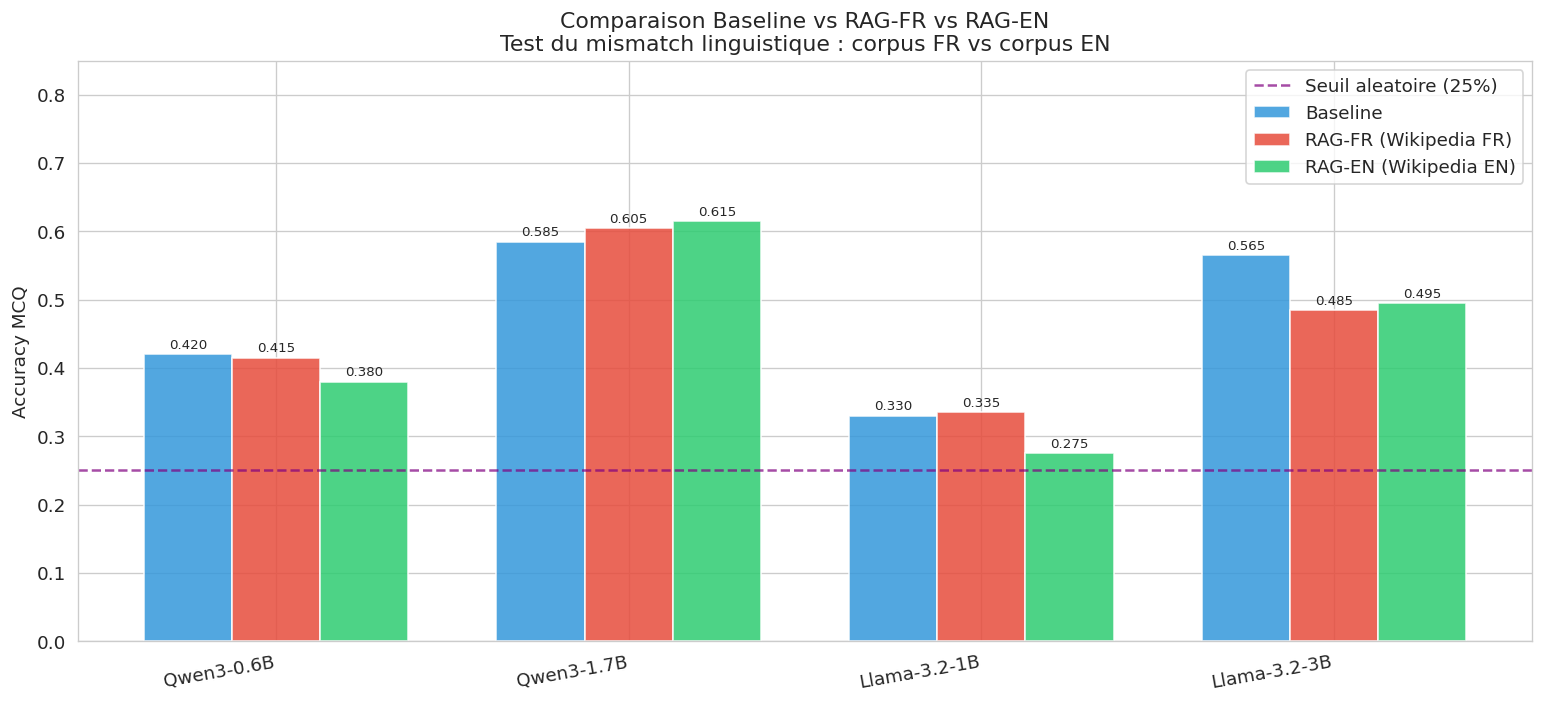

Figure 1 sauvegardee.


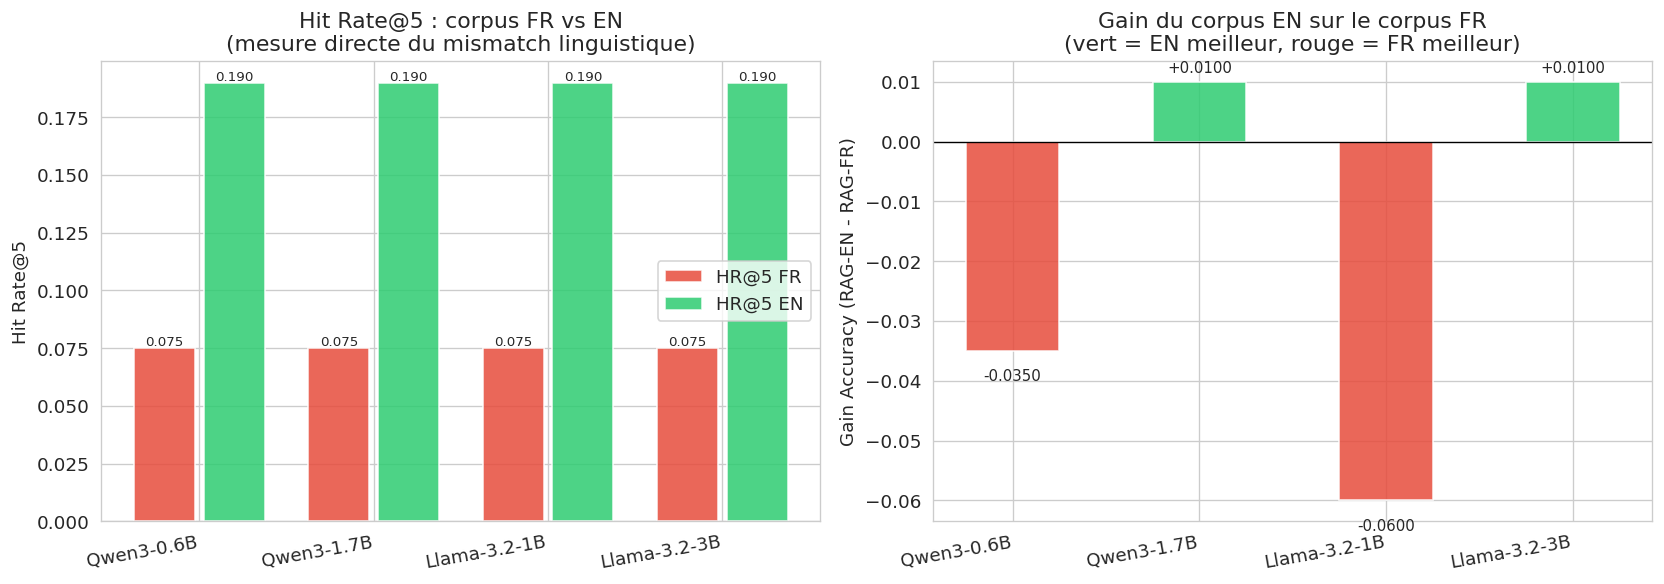

Figure 2 sauvegardee.


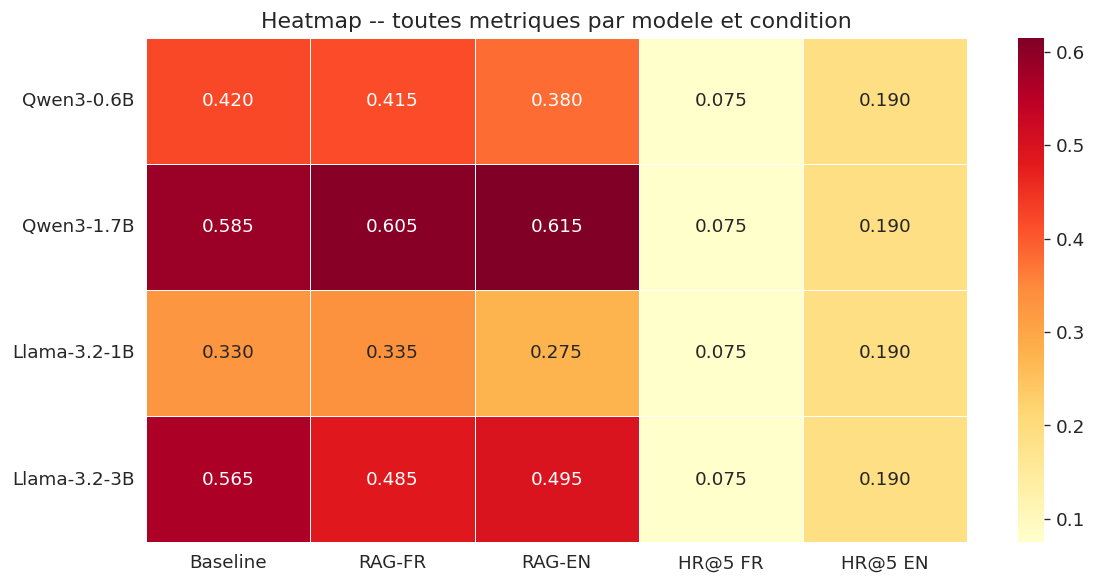

Figure 3 sauvegardee.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

model_names   = df_comparison['Modele'].tolist()
n_models      = len(model_names)
x             = np.arange(n_models)
width         = 0.25

base_accs  = df_comparison['Baseline Acc'].values.astype(float)
fr_accs    = df_comparison['RAG-FR Acc'].values.astype(float)
en_accs    = df_comparison['RAG-EN Acc'].values.astype(float)
hr_fr      = df_comparison['HR@5 FR'].values.astype(float)
hr_en      = df_comparison['HR@5 EN'].values.astype(float)
gain_en_fr = df_comparison['Gain EN-FR (abs)'].values.astype(float)

# ---- Figure 1 : Accuracy Baseline / RAG-FR / RAG-EN -------------------------
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, base_accs, width, label='Baseline',
            color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar(x,          fr_accs,  width, label='RAG-FR (Wikipedia FR)',
            color='#e74c3c', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + width,  en_accs,  width, label='RAG-EN (Wikipedia EN)',
            color='#2ecc71', alpha=0.85, edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)
ax.axhline(y=0.25, color='purple', linestyle='--', linewidth=1.5,
           label='Seuil aleatoire (25%)', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.set_ylabel('Accuracy MCQ')
ax.set_ylim(0, max(en_accs.max(), base_accs.max()) * 1.3 + 0.05)
ax.set_title('Comparaison Baseline vs RAG-FR vs RAG-EN\n'
             'Test du mismatch linguistique : corpus FR vs corpus EN')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_baseline_ragfr_ragen.png', bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardee.")

# ---- Figure 2 : HR@5 FR vs EN + Gain EN-FR ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - 0.2, hr_fr, 0.35, label='HR@5 FR', color='#e74c3c', alpha=0.85)
axes[0].bar(x + 0.2, hr_en, 0.35, label='HR@5 EN', color='#2ecc71', alpha=0.85)
for i, (f, e) in enumerate(zip(hr_fr, hr_en)):
    axes[0].text(i-0.2, f+0.001, f'{f:.3f}', ha='center', fontsize=8)
    axes[0].text(i+0.2, e+0.001, f'{e:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].set_ylabel('Hit Rate@5')
axes[0].set_title('Hit Rate@5 : corpus FR vs EN\n'
                  '(mesure directe du mismatch linguistique)')
axes[0].legend()

colors_g = ['#2ecc71' if g >= 0 else '#e74c3c' for g in gain_en_fr]
bars_g   = axes[1].bar(x, gain_en_fr, 0.5, color=colors_g, alpha=0.85, edgecolor='white')
for bar in bars_g:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 h + (0.001 if h >= 0 else -0.003),
                 f'{h:+.4f}', ha='center',
                 va='bottom' if h >= 0 else 'top', fontsize=9)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=10, ha='right')
axes[1].set_ylabel('Gain Accuracy (RAG-EN - RAG-FR)')
axes[1].set_title('Gain du corpus EN sur le corpus FR\n'
                  '(vert = EN meilleur, rouge = FR meilleur)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_mismatch_analysis.png', bbox_inches='tight')
plt.show()
print("Figure 2 sauvegardee.")

# ---- Figure 3 : Heatmap complete --------------------------------------------
metrics_df = pd.DataFrame({
    'Baseline': base_accs,
    'RAG-FR':   fr_accs,
    'RAG-EN':   en_accs,
    'HR@5 FR':  hr_fr,
    'HR@5 EN':  hr_en,
}, index=model_names)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap -- toutes metriques par modele et condition')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_heatmap_metrics.png', bbox_inches='tight')
plt.show()
print("Figure 3 sauvegardee.")


## Étape 7 — Analyse des facteurs

Analyse multi-dimensionnelle des résultats :
- Effet de la taille du modèle
- Effet de la famille de modèle
- Impact du RAG
- Latence et efficacité
- Comparaison de la difficulté GKMC vs GeoSQA

In [9]:
import json
import os

# Charger les résultats Phase2a depuis Google Drive
PHASE2A_JSON = 'phase2a_all_results.json'

if os.path.exists(PHASE2A_JSON):
    with open(PHASE2A_JSON, 'r', encoding='utf-8') as f:
        phase2a_results = json.load(f)
    print(f"Résultats Phase2a chargés : {len(phase2a_results['results'])} modèles")
else:
    print(f"Fichier non trouvé : {PHASE2A_JSON}")
    print("Utilisation des valeurs hardcodées à la place.")
    phase2a_results = None

Résultats Phase2a chargés : 5 modèles


In [10]:
# == Facteur 1 : Taille du modèle =============================================
print("=" * 60)
print("ANALYSE — Facteur : Taille du modèle")
print("=" * 60)
for _, row in df_comparison.sort_values('Taille (B)').iterrows():
    print(f"  {row['Modele']:20s} ({row['Taille (B)']:.1f}B) : "
          f"Baseline Acc={row['Baseline Acc']:.4f}, "
          f"RAG Acc={row['RAG Acc']:.4f}")

# Corrélation taille vs accuracy
if len(df_comparison) >= 3:
    from scipy import stats
    corr, p_val = stats.pearsonr(df_comparison['Taille (B)'], df_comparison['RAG Acc'])
    print(f"\n  Corrélation (Pearson) Taille vs RAG Acc : r={corr:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  --> Corrélation significative (p < 0.05)")
    else:
        print(f"  --> Corrélation non significative (p >= 0.05)")

# == Facteur 2 : Famille de modèle ============================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Famille de modèle")
print("=" * 60)
family_means = df_comparison.groupby('Famille').agg({
    'RAG Acc': 'mean',
    'RAG F1': 'mean',
    'Baseline Acc': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'mean'
}).round(4)
print(family_means.to_string())

print(f"\n  Meilleure famille (RAG Acc moyenne) : {family_means['RAG Acc'].idxmax()} "
      f"({family_means['RAG Acc'].max():.4f})")

# == Facteur 3 : Impact du RAG par modèle =====================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Impact du RAG")
print("=" * 60)
for _, row in df_comparison.iterrows():
    delta = row['Delta Acc']
    if delta > 0.02:
        impact = "POSITIF"
    elif delta < -0.02:
        impact = "NÉGATIF"
    else:
        impact = "NEUTRE"
    print(f"  {row['Modele']:20s} : delta={row['Delta Acc']:+.4f} ({impact})")

avg_delta = df_comparison['Delta Acc'].mean()
print(f"\n  Impact moyen du RAG sur l'Accuracy : {avg_delta:+.4f}")
n_positive = (df_comparison['Delta Acc'] > 0).sum()
print(f"  Modèles améliorés par le RAG : {n_positive}/{len(df_comparison)}")

# == Facteur 4 : Latence ======================================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Latence (temps/question)")
print("=" * 60)
for _, row in df_comparison.iterrows():
    time_baseline = row['Temps Baseline (s)'] / MAX_QUESTIONS
    time_rag = row['Temps RAG (s)'] / MAX_QUESTIONS
    overhead = time_rag - time_baseline
    print(f"  {row['Modele']:20s} : "
          f"Baseline={time_baseline:.2f}s/q, "
          f"RAG={time_rag:.2f}s/q, "
          f"Overhead={overhead:+.2f}s/q")

# == Facteur 5 : Efficacité (Accuracy / Taille) ===============================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Efficacité (RAG Acc / Taille)")
print("=" * 60)
df_comparison['Efficacité'] = df_comparison['RAG Acc'] / df_comparison['Taille (B)']
for _, row in df_comparison.sort_values('Efficacité', ascending=False).iterrows():
    print(f"  {row['Modele']:20s} : Efficacité={row['Efficacité']:.4f} "
          f"(Acc={row['RAG Acc']:.4f} / {row['Taille (B)']:.1f}B)")

# == Facteur 6 : Comparaison difficulté GKMC vs GeoSQA ========================
print(f"\n{'='*60}")
print("ANALYSE — Comparaison de difficulté GKMC vs GeoSQA")
print("=" * 60)
if phase2a_results is not None:
    p2a_accs = []
    p2b_accs = []
    for model_name in MODELS.keys():
        p2a_res = phase2a_results.get('results', {}).get(model_name, {})
        p2b_res = all_results.get(model_name, {})
        if 'error' not in p2a_res and 'error' not in p2b_res and p2a_res and p2b_res:
            p2a_accs.append(p2a_res.get('rag', {}).get('accuracy', 0))
            p2b_accs.append(p2b_res.get('rag', {}).get('accuracy', 0))

    if p2a_accs and p2b_accs:
        avg_geosqa = np.mean(p2a_accs)
        avg_gkmc = np.mean(p2b_accs)
        print(f"  Accuracy RAG moyenne GeoSQA : {avg_geosqa:.4f}")
        print(f"  Accuracy RAG moyenne GKMC   : {avg_gkmc:.4f}")
        diff = avg_gkmc - avg_geosqa
        if diff > 0.02:
            print(f"  --> GKMC semble PLUS FACILE que GeoSQA (delta: {diff:+.4f})")
        elif diff < -0.02:
            print(f"  --> GKMC semble PLUS DIFFICILE que GeoSQA (delta: {diff:+.4f})")
        else:
            print(f"  --> Difficulté COMPARABLE entre GKMC et GeoSQA (delta: {diff:+.4f})")
    else:
        print("  Pas assez de données pour la comparaison.")
else:
    print("  Résultats Phase 2a non disponibles.")
    print("  La comparaison sera possible après exécution de Phase2a et Phase2b.")
    avg_gkmc = df_comparison['RAG Acc'].mean()
    print(f"  Accuracy RAG moyenne GKMC : {avg_gkmc:.4f}")

ANALYSE — Facteur : Taille du modèle
  Qwen3-0.6B           (0.6B) : Baseline Acc=0.4200, RAG Acc=0.4150
  Llama-3.2-1B         (1.0B) : Baseline Acc=0.3300, RAG Acc=0.3350
  Qwen3-1.7B           (1.7B) : Baseline Acc=0.5850, RAG Acc=0.6050
  Llama-3.2-3B         (3.0B) : Baseline Acc=0.5650, RAG Acc=0.4850

  Corrélation (Pearson) Taille vs RAG Acc : r=0.4687, p=0.5313
  --> Corrélation non significative (p >= 0.05)

ANALYSE — Facteur : Famille de modèle
         RAG Acc  RAG F1  Baseline Acc  Delta Acc  Taille (B)
Famille                                                      
Llama       0.41     0.0        0.4475    -0.0375        2.00
Qwen        0.51     0.0        0.5025     0.0075        1.15

  Meilleure famille (RAG Acc moyenne) : Qwen (0.5100)

ANALYSE — Facteur : Impact du RAG
  Qwen3-0.6B           : delta=-0.0050 (NEUTRE)
  Qwen3-1.7B           : delta=+0.0200 (POSITIF)
  Llama-3.2-1B         : delta=+0.0050 (NEUTRE)
  Llama-3.2-3B         : delta=-0.0800 (NÉGATIF)

  Impac

## Étape 8 — Analyse qualitative

Examen des cas où les modèles divergent dans leurs prédictions,
pour comprendre les forces et faiblesses de chaque LLM sur le dataset GKMC.

In [11]:
# == Analyse des désaccords entre modèles ======================================
print("=" * 60)
print("ANALYSE QUALITATIVE — Désaccords entre modèles")
print("=" * 60)

# Collecter les prédictions RAG de chaque modèle
model_predictions = {}
for name, res in all_results.items():
    if 'error' in res:
        continue
    model_predictions[name] = res['predictions']['rag_letters']

valid_models = list(model_predictions.keys())

if len(valid_models) >= 2:
    # Trouver les questions où les modèles ne sont pas d'accord
    disagreements = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        unique_preds = set(preds_i.values())
        if len(unique_preds) > 1:
            correct = correct_letters[i]
            n_correct = sum(1 for p in preds_i.values() if p.upper() == correct.upper())
            disagreements.append({
                'index': i,
                'question': questions[i][:200],
                'correct': correct,
                'predictions': preds_i,
                'n_correct': n_correct,
            })

    print(f"\n  Nombre de désaccords : {len(disagreements)} / {MAX_QUESTIONS} "
          f"({len(disagreements)/MAX_QUESTIONS*100:.1f}%)")
    print(f"  Nombre d'accords unanimes : {MAX_QUESTIONS - len(disagreements)}")

    # Montrer les 10 premiers désaccords
    print(f"\n  --- Exemples de désaccords ---")
    for j, d in enumerate(disagreements[:10]):
        print(f"\n  Question {d['index']} : {d['question']}")
        print(f"    Réponse correcte : {d['correct']}")
        for m, p in d['predictions'].items():
            status = "OK" if p.upper() == d['correct'].upper() else "FAUX"
            print(f"    {m:20s} : {p} ({status})")

    # Matrice d'accord entre modèles
    print(f"\n  --- Matrice d'accord (proportion) ---")
    if len(valid_models) >= 2:
        agreement_matrix = {}
        for m1 in valid_models:
            agreement_matrix[m1] = {}
            for m2 in valid_models:
                agreement = sum(
                    1 for i in range(MAX_QUESTIONS)
                    if model_predictions[m1][i].upper() == model_predictions[m2][i].upper()
                ) / MAX_QUESTIONS
                agreement_matrix[m1][m2] = agreement

        df_agreement = pd.DataFrame(agreement_matrix)
        print(df_agreement.round(3).to_string())

    # Vote majoritaire
    print(f"\n  --- Vote majoritaire ---")
    majority_correct = 0
    for i in range(MAX_QUESTIONS):
        preds_i = [model_predictions[m][i].upper() for m in valid_models]
        vote_counts = Counter(preds_i)
        majority_vote = vote_counts.most_common(1)[0][0]
        if majority_vote == correct_letters[i].upper():
            majority_correct += 1
    majority_acc = majority_correct / MAX_QUESTIONS
    print(f"  Accuracy du vote majoritaire : {majority_acc:.4f}")
    print(f"  (comparé au meilleur modèle individuel : {df_comparison['RAG Acc'].max():.4f})")

    # Exemples de succès et échecs
    print(f"\n  --- Exemples de succès unanimes ---")
    unanime_correct = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        if all(p.upper() == correct_letters[i].upper() for p in preds_i.values()):
            unanime_correct.append(i)
    print(f"  Questions correctement répondues par tous : {len(unanime_correct)}/{MAX_QUESTIONS}")
    for idx in unanime_correct[:3]:
        print(f"    Q{idx}: {questions[idx][:150]}...")

    print(f"\n  --- Exemples d'échecs unanimes ---")
    unanime_wrong = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        if all(p.upper() != correct_letters[i].upper() for p in preds_i.values()):
            unanime_wrong.append(i)
    print(f"  Questions ratées par tous : {len(unanime_wrong)}/{MAX_QUESTIONS}")
    for idx in unanime_wrong[:3]:
        print(f"    Q{idx}: {questions[idx][:150]}...")
        print(f"      Réponse correcte : {correct_letters[idx]}")

else:
    print("  Pas assez de modèles valides pour l'analyse qualitative.")

ANALYSE QUALITATIVE — Désaccords entre modèles

  Nombre de désaccords : 166 / 200 (83.0%)
  Nombre d'accords unanimes : 34

  --- Exemples de désaccords ---

  Question 0 : What impact has the new town construction had on Hong Kong?
    Réponse correcte : D
    Qwen3-0.6B           : A (FAUX)
    Qwen3-1.7B           : A (FAUX)
    Llama-3.2-1B         : D (OK)
    Llama-3.2-3B         : D (OK)

  Question 1 : In recent years, developed countries have experienced a phenomenon of counter-urbanization, with urban populations migrating to suburban, rural settlements, and small towns. The reason for this is not
    Réponse correcte : C
    Qwen3-0.6B           : D (FAUX)
    Qwen3-1.7B           : C (OK)
    Llama-3.2-1B         : C (OK)
    Llama-3.2-3B         : A (FAUX)

  Question 3 : The fundamental cause of the current deterioration of the urban ecological environment is:
    Réponse correcte : B
    Qwen3-0.6B           : D (FAUX)
    Qwen3-1.7B           : B (OK)
    Llama-3.2-1B 

## Étape 9 — Sauvegarde des résultats

In [12]:
import json

# == Sauvegarde JSON — Tous les résultats =====================================
# Créer une version sérialisable (sans les listes de prédictions)
results_json = {}
for name, res in all_results.items():
    if 'error' in res:
        results_json[name] = res
        continue
    results_json[name] = {
        'model_id': res['model_id'],
        'family': res['family'],
        'size_B': res['size_B'],
        'baseline': res['baseline'],
        'rag': res['rag'],
        'retrieval': res['retrieval'],
        'improvement': res['improvement'],
    }

# Ajouter les métadonnées
output_json = {
    'phase': '2b',
    'dataset': 'GKMC',
    'description': 'Comparaison Multi-LLMs sur GKMC avec RAG',
    'config': CONFIG,
    'n_questions': MAX_QUESTIONS,
    'n_models': len(MODELS),
    'results': results_json,
}

json_path = f'{RESULTS_DIR}/phase2b_all_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"Résultats JSON sauvegardés : {json_path}")

# == Sauvegarde CSV — Tableau comparatif ======================================
csv_path = f'{RESULTS_DIR}/phase2b_comparison.csv'
df_comparison.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Tableau comparatif CSV sauvegardé : {csv_path}")

# == Sauvegarde CSV — Prédictions détaillées ==================================
pred_rows = []
for i in range(MAX_QUESTIONS):
    row = {
        'index': i,
        'question': questions[i][:500],
        'correct_letter': correct_letters[i],
        'correct_text': correct_texts[i][:200],
    }
    for name, res in all_results.items():
        if 'error' in res:
            continue
        row[f'{name}_baseline'] = res['predictions']['baseline_letters'][i]
        row[f'{name}_rag'] = res['predictions']['rag_letters'][i]
        row[f'{name}_baseline_ok'] = 1 if res['predictions']['baseline_letters'][i].upper() == correct_letters[i].upper() else 0
        row[f'{name}_rag_ok'] = 1 if res['predictions']['rag_letters'][i].upper() == correct_letters[i].upper() else 0
    pred_rows.append(row)

df_predictions = pd.DataFrame(pred_rows)
pred_csv_path = f'{RESULTS_DIR}/phase2b_predictions.csv'
df_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
print(f"Prédictions détaillées CSV sauvegardées : {pred_csv_path}")

# == Affichage résumé ==========================================================
print(f"\n{'='*60}")
print(f"FICHIERS GÉNÉRÉS")
print(f"{'='*60}")
print(f"  {json_path}")
print(f"  {csv_path}")
print(f"  {pred_csv_path}")
print(f"  {RESULTS_DIR}/phase2b_fig1_accuracy_baseline_vs_rag.png")
print(f"  {RESULTS_DIR}/phase2b_fig2_size_vs_accuracy.png")
print(f"  {RESULTS_DIR}/phase2b_fig3_*.png")
print(f"  {RESULTS_DIR}/phase2b_fig4_improvement_delta.png")

# == Sauvegarde optionnelle sur Google Drive ===================================
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2b/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            src = os.path.join(RESULTS_DIR, fname)
            dst = os.path.join(drive_dest, fname)
            shutil.copy2(src, dst)
            print(f"Copie : {dst}")

        print(f"\nTous les résultats ont été copiés sur Google Drive : {drive_dest}")

    except ImportError:
        print("\nGoogle Drive non disponible (environnement non-Colab).")
    except Exception as e:
        print(f"\nErreur lors de la sauvegarde sur Google Drive : {e}")

Résultats JSON sauvegardés : results/phase2b_all_results.json
Tableau comparatif CSV sauvegardé : results/phase2b_comparison.csv
Prédictions détaillées CSV sauvegardées : results/phase2b_predictions.csv

FICHIERS GÉNÉRÉS
  results/phase2b_all_results.json
  results/phase2b_comparison.csv
  results/phase2b_predictions.csv
  results/phase2b_fig1_accuracy_baseline_vs_rag.png
  results/phase2b_fig2_size_vs_accuracy.png
  results/phase2b_fig3_*.png
  results/phase2b_fig4_improvement_delta.png

Erreur lors de la sauvegarde sur Google Drive : Error: credential propagation was unsuccessful


## Résumé Phase 2b — GKMC

### Configuration
- Dataset : GKMC (Geographic Knowledge Multiple Choice, 200 questions, EN natif)
- Corpus testé : Wikipedia FR (300 articles) + Wikipedia EN (300 articles)
- Retriever : BAAI/bge-m3 + FAISS (IndexFlatIP)
- GPU : Tesla T4 (15.6 Go)
- Pas de colonne `scenario` dans GKMC (contrairement à GeoSQA)

### Métriques de retrieval (indépendantes du LLM)
| Corpus | HR@5 | MRR@5 | Facteur vs FR |
|--------|------|-------|---------------|
| Wikipedia FR | 0.0750 | 0.0464 | ×1.0 (référence) |
| Wikipedia EN | **0.1900** | **0.1187** | **×2.5** |

→ **Mismatch linguistique CONFIRMÉ** : le corpus EN améliore le HR@5 d'un facteur ×2.5.
BGE-m3 encode correctement — c'était le corpus FR qui limitait le retrieval.

### Classement des modèles
| Rang | Modèle | Baseline | RAG-FR | Δrel FR | RAG-EN | Δrel EN |
|------|--------|----------|--------|---------|--------|---------|
| 1 | Qwen3-1.7B | 0.5850 | **0.6050** | +3.4% | **0.6150** | +5.1% |
| 2 | Llama-3.2-3B | **0.5650** | 0.4850 | -14.2% | 0.4950 | -12.4% |
| 3 | Qwen3-0.6B | 0.4200 | 0.4150 | -1.2% | 0.3800 | -9.5% |
| 4 | Llama-3.2-1B | 0.3300 | 0.3350 | +1.5% | 0.2750 | -16.7% |
| 5 | Ministral-3B | ERREUR | ERREUR | — | ERREUR | — |

### Gain EN vs FR (accuracy)
| Modèle | RAG-FR | RAG-EN | Gain EN−FR (abs) | Gain EN−FR (rel%) |
|--------|--------|--------|------------------|-------------------|
| Qwen3-1.7B | 0.6050 | 0.6150 | +0.0100 | +1.7% |
| Llama-3.2-3B | 0.4850 | 0.4950 | +0.0100 | +2.1% |
| Qwen3-0.6B | 0.4150 | 0.3800 | -0.0350 | -8.4% |
| Llama-3.2-1B | 0.3350 | 0.2750 | -0.0600 | -17.9% |
| **Moyenne** | **0.4600** | **0.4413** | **-0.0187** | **-5.6%** |

→ Contrairement à GeoSQA, le corpus EN n'améliore pas l'accuracy moyenne sur GKMC (-5.6%).
Les modèles Qwen bénéficient légèrement du corpus EN, les modèles Llama en souffrent.

### Analyse des facteurs

**Facteur 1 — Famille du modèle**
- Qwen (RAG-FR moy.) : 0.5100 > Llama (RAG-FR moy.) : 0.4100
- Qwen domine sur GKMC comme sur GeoSQA

**Facteur 2 — Taille du modèle (intra-famille)**
- Qwen : 0.6B→1.7B : +45.8% (RAG-FR) → taille aide fortement
- Llama : 1B→3B : +44.8% (RAG-FR) → taille aide fortement
- Corrélation globale Pearson : r=0.469, p=0.531 (non significatif, n=4)

**Facteur 3 — Impact du RAG**
- RAG-FR : impact moyen = -1.5% (quasi-nul, légèrement négatif)
- Qwen3-1.7B : +3.4% (POSITIF) — seul modèle vraiment amélioré par RAG-FR
- Llama-3.2-3B : -14.2% (NÉGATIF) — forte dégradation malgré bonne baseline
- 2/4 modèles améliorés ou neutres avec RAG-FR

**Facteur 4 — Latence (overhead RAG)**
| Modèle | Baseline (s/q) | RAG-FR (s/q) | Overhead |
|--------|----------------|--------------|----------|
| Qwen3-0.6B | 0.46 | 0.75 | +0.29 |
| Qwen3-1.7B | 0.44 | 1.27 | +0.83 |
| Llama-3.2-1B | 0.75 | 1.50 | +0.75 |
| Llama-3.2-3B | 0.68 | 2.39 | +1.71 |

**Facteur 5 — Efficacité (RAG-FR Acc / Taille)**
- Qwen3-0.6B : 0.6917 (meilleure efficacité)
- Qwen3-1.7B : 0.3559
- Llama-3.2-1B : 0.3350
- Llama-3.2-3B : 0.1617

**Facteur 6 — Comparaison GKMC vs GeoSQA**
| Modèle | GeoSQA RAG-FR | GKMC RAG-FR | Delta |
|--------|--------------|-------------|-------|
| Qwen3-0.6B | 0.2600 | 0.4150 | +0.1550 |
| Qwen3-1.7B | 0.3350 | 0.6050 | +0.2700 |
| Llama-3.2-1B | 0.2050 | 0.3350 | +0.1300 |
| Llama-3.2-3B | 0.2300 | 0.4850 | +0.2550 |
| **Moyenne** | **0.2575** | **0.4600** | **+0.2025** |

→ **GKMC est significativement plus facile que GeoSQA** (+20.25 pts abs en moyenne).
Questions factuelles EN natif vs questions ZH→EN plus abstraites.

### Analyse qualitative
- Taux de désaccord inter-modèles : **83.0%** (166/200 questions)
- Accords unanimes corrects : 26/200 (13.0%)
- Échecs unanimes : 34/200 (17.0%) — questions difficiles pour tous
- Vote majoritaire : **0.4900** < meilleur individuel (0.6050 Qwen3-1.7B)
- Matrice d'accord : 33.5% à 52.0% entre paires de modèles (meilleur accord que GeoSQA)

### Conclusions

1. **GKMC plus facile que GeoSQA** : accuracy RAG-FR moyenne = 0.4600 vs 0.2575 sur GeoSQA (+78.6% relatif). Les questions en anglais natif sur des faits géographiques factuels sont mieux maîtrisées par tous les modèles.

2. **Mismatch confirmé au niveau retrieval** : HR@5 passe de 0.075 (FR) à 0.190 (EN), facteur ×2.5. BGE-m3 retrouve mieux les documents EN pour des questions EN.

3. **Mais corpus EN ne se traduit pas en gain d'accuracy** : contrairement à GeoSQA où RAG-EN aidait Llama (+18.5% et +5.5%), sur GKMC le gain EN-FR moyen est de -5.6%. Les modèles Llama souffrent du corpus EN (-16.7% pour Llama-3.2-1B). Cela suggère que sur GKMC, les modèles répondent déjà correctement depuis leurs connaissances internes — le contexte supplémentaire perturbe.

4. **Qwen3-1.7B domine** : meilleur RAG-FR (0.6050) et RAG-EN (0.6150). Seul modèle qui bénéficie du RAG dans les deux conditions (+3.4% et +5.1%).

5. **Llama-3.2-3B paradoxe** : meilleure baseline (0.5650) mais forte dégradation RAG (-14.2%). Ses connaissances internes sont solides sur GKMC, le contexte RAG le perturbe.

6. **Vote majoritaire sous-performant** : 0.4900 < Qwen3-1.7B (0.6050). Les erreurs se concentrent sur les mêmes questions difficiles (34 échecs unanimes).

7. **Ministral-3B incompatible** : Mistral3Config non supportée par AutoModelForCausalLM. Résultats non disponibles.

### Métriques RAGAS — Non implémentées
RAGAS n'a pas été intégré dans ce notebook (contraintes GPU T4, dépendance LLM juge externe, incompatibilité format MCQ).
Voir justification détaillée dans la section §5.4 du rapport.

### Prochaines étapes
- **Phase 2c** : Évaluation sur Tourism-QA (corpus EN natif, questions ouvertes)
- **Phase 2d** : Analyse factorielle croisée (modèles × datasets × corpus FR/EN)
